In [2]:
!pip install qiskit
!pip install pylatexenc
#after installing pylatexenc. Go to Runtime >> Restart Session

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 75.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 83.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.4/54.4 kB 4.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 8.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=cac797a1ef345e218a308c70815626fed7b3f02423582eb739bc2688c54e6b1b
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


In [3]:
from qiskit import *
from qiskit.visualization import plot_bloch_multivector, visualize_transition, plot_histogram

In [4]:
# Create a quantum circuit with 2 qubits
# The default initial state of qubits will be |0> or [1,0]
qc = QuantumCircuit(2)

In [5]:
#Applying the hadarmad gate to target
qc.h(1)
#apply the cx gate to both qubits
qc.cx(0,1)
#Applying the hadarmad gate to target
qc.h(1)

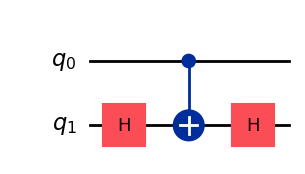

In [6]:
#Draw the circuit
qc.draw('mpl')

In [7]:
!pip install qiskit-aer
from qiskit import QuantumCircuit
from qiskit_aer import Aer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 57.3 MB/s eta 0:00:00


In [8]:
#Get the backend for the circuit to display unitary matrix
backend = Aer.get_backend('unitary_simulator')

In [9]:
#execute the circuit using the backend
job = backend.run(qc)
out = job.result().get_unitary(qc)

In [10]:
#import qiskit_textbook and display the combined unitary matrix
#from qiskit_textbook.tools import array_to_latex
#array_to_latex(out, pretext = "\\text{UnitaryMatrix} = ")

In [11]:
#custom function to convert array to latex, coz existing function was depricated
import numpy as np
from IPython.display import display, Math

def array_to_latex(arr, name="U", precision=2):
    # Convert Operator → NumPy array if needed
    arr = np.asarray(arr)

    def format_complex(z):
        if np.isclose(z.imag, 0):
            return f"{z.real:.{precision}g}"
        if np.isclose(z.real, 0):
            return f"{z.imag:.{precision}g}i"
        sign = "+" if z.imag >= 0 else "-"
        return f"{z.real:.{precision}g} {sign} {abs(z.imag):.{precision}g}i"

    latex = r"\begin{bmatrix}"
    for row in arr:
        latex += " & ".join(format_complex(x) for x in row) + r"\\"
    latex += r"\end{bmatrix}"

    display(Math(rf"\text{{{name}}} = {latex}"))

In [12]:
array_to_latex(out)

<IPython.core.display.Math object>

In [13]:
#Get the backend for the circuit (simulator or realtime system)
backend = Aer.get_backend('statevector_simulator')

In [14]:
#execute the circuit using the backend
#out = execute(qc,backend).result().get_statevector()
job = backend.run(qc)
out = job.result().get_statevector(qc)

In [15]:
import numpy as np
from IPython.display import display, Math

#custom function to convert statevector to latex
def statevector_to_latex(vec, name=r"\ket{\psi}"):
    vec = np.asarray(vec)   # <-- IMPORTANT
    latex = r"\begin{bmatrix}"
    for amp in vec:
        latex += f"{amp:.3g}\\\\"
    latex += r"\end{bmatrix}"
    display(Math(rf"{name} = {latex}"))

In [16]:
#import qiskit_textbook and display the statevector
#from qiskit_textbook.tools import array_to_latex
statevector_to_latex(out)

<IPython.core.display.Math object>

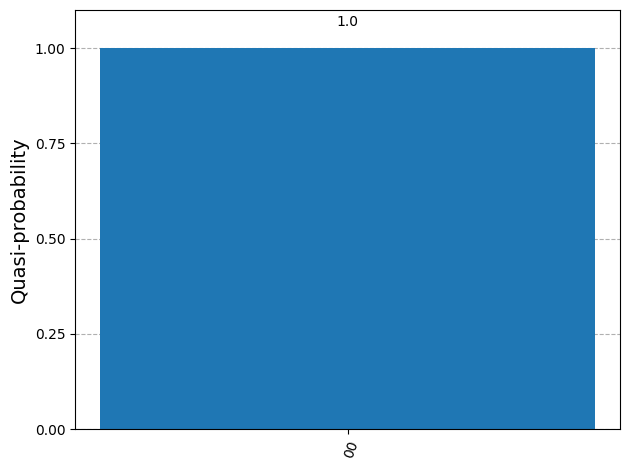

In [17]:
#execute the circuit and get the plain result
job = backend.run(qc, shots=1024)
out = job.result()
#getting the count of the result
counts = out.get_counts()
#plotting the histogram
plot_histogram(counts)